# Project 01 — Customer Churn Risk

**Goal:** predict whether a subscription customer will churn in the next billing cycle.

The project brief requires Logistic Regression, an evaluation using Accuracy, Precision, Recall, F1-score and ROC-AUC, a confusion matrix, coefficient interpretation, and a short discussion of limitations.

`target = 1` means the customer churned, while `target = 0` means the customer did not churn.


In [19]:
# Libraries used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

pd.set_option("display.max_columns", None)


## 1. Load and inspect the data

I first load the dataset and check what the columns look like before making any changes. This makes it easier to spot obvious problems early.


In [20]:

data_path = Path("dataset_01_customer_churn_risk.csv")

df = pd.read_csv(data_path)

df.head()


,tenure_months,monthly_charges,support_tickets,avg_session_minutes,late_payments,contract_months,target
0,52,54.79,7,10.66,2,12,0
1,11,167.15,4,46.99,3,37,1
2,2,184.92,3,65.38,7,35,1
3,39,271.21,2,22.19,4,10,0
4,22,66.33,5,46.77,3,33,1


In [21]:
# Basic size and structure of the dataset
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Shape: (1000, 7)

Column names:
['tenure_months', 'monthly_charges', 'support_tickets', 'avg_session_minutes', 'late_payments', 'contract_months', 'target']

Data types:
tenure_months            int64
monthly_charges        float64
support_tickets          int64
avg_session_minutes    float64
late_payments            int64
contract_months          int64
target                   int64
dtype: object


### Variables

The six predictor variables are:

- `tenure_months` — how long the customer has been with the service.
- `monthly_charges` — the customer's monthly subscription charges.
- `support_tickets` — number of support tickets.
- `avg_session_minutes` — average session duration.
- `late_payments` — number of late payments.
- `contract_months` — length of the customer's contract.

The target is `target`, where 1 represents churn and 0 represents no churn.


In [22]:
# Summary statistics give a quick idea of the ranges and spread
df.describe().T


,count,mean,std,min,25%,50%,75%,max
tenure_months,1000.0,30.12100,17.216526,1.00,15.0000,30.000,45.0000,60.00
monthly_charges,1000.0,182.73827,144.743232,16.81,89.6100,144.690,232.2875,1530.68
support_tickets,1000.0,3.12900,1.772428,0.00,2.0000,3.000,4.0000,11.00
avg_session_minutes,1000.0,35.51145,19.954864,2.00,20.1525,35.085,49.6900,103.35
late_payments,1000.0,3.08100,1.763959,0.00,2.0000,3.000,4.0000,10.00
contract_months,1000.0,30.23400,17.254186,1.00,15.0000,31.000,45.0000,60.00
target,1000.0,0.50000,0.500250,0.00,0.0000,0.500,1.0000,1.00


## 2. Data-quality checks

Before modelling, I check missing values, duplicate rows, class balance and possible unusual values.


In [23]:
# Missing values in each column
df.isna().sum()


tenure_months          0
monthly_charges        0
support_tickets        0
avg_session_minutes    0
late_payments          0
contract_months        0
target                 0
dtype: int64

In [24]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)


Duplicate rows: 0


In [25]:
# Class balance
class_counts = df["target"].value_counts().sort_index()
class_percentages = df["target"].value_counts(normalize=True).sort_index() * 100

balance_table = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2)
})

balance_table


,count,percentage
target,,
0,500,50.0
1,500,50.0


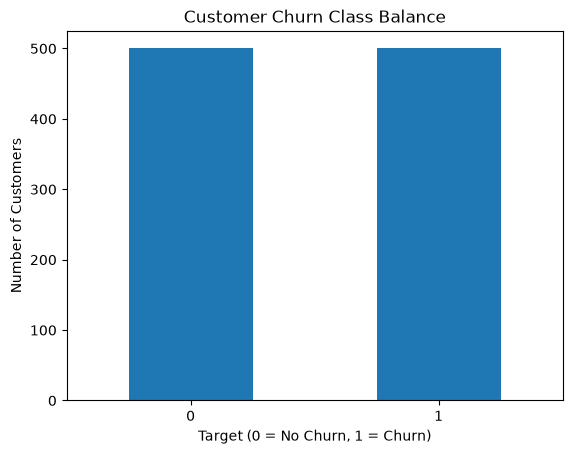

In [26]:
# A simple view of the target balance
class_counts.plot(kind="bar")
plt.title("Customer Churn Class Balance")
plt.xlabel("Target (0 = No Churn, 1 = Churn)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()


In [27]:
# IQR is useful for flagging unusually large or small numerical values.
# I am only flagging them here, not deleting them automatically.
outlier_summary = []

for column in df.drop(columns="target").columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    outlier_summary.append({
        "feature": column,
        "outliers_flagged": int(outlier_count),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2)
    })

pd.DataFrame(outlier_summary)


,feature,outliers_flagged,lower_bound,upper_bound
0,tenure_months,0,-30.00,90.0
1,monthly_charges,42,-124.41,446.3
2,support_tickets,21,-1.00,7.0
3,avg_session_minutes,1,-24.15,94.0
4,late_payments,19,-1.00,7.0
5,contract_months,0,-30.00,90.0


The dataset has no missing values and no duplicate rows. The target is also perfectly balanced, with the same number of churn and non-churn customers.

The IQR check flags some extreme values, especially in `monthly_charges`, but the project brief does not give valid business limits for these variables. Because of that, I do not remove or cap them without evidence that they are incorrect. They are kept in the model, and this is noted as a limitation.


## 3. Exploratory analysis

I look at the relationship between the predictors and the target. This is not used to manually choose the answer; it is just a quick check of how the variables relate to churn.


In [28]:
# Correlation with the target
correlations = df.corr(numeric_only=True)["target"].drop("target").sort_values()

correlations


support_tickets       -0.207164
late_payments         -0.168456
tenure_months         -0.159055
contract_months        0.201443
avg_session_minutes    0.208914
monthly_charges        0.217740
Name: target, dtype: float64

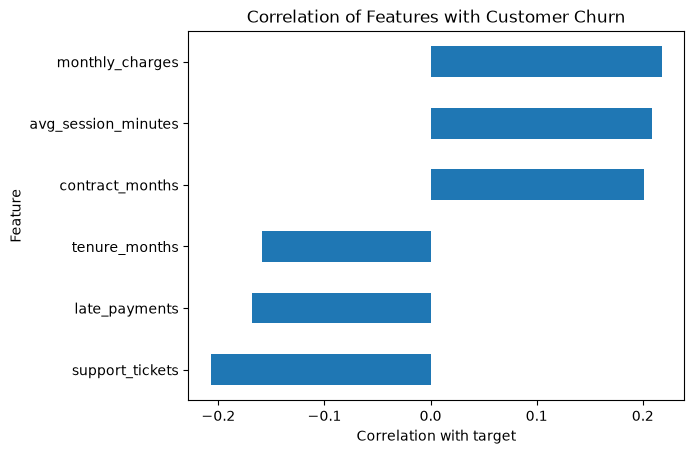

In [29]:
# Plot the feature correlations with churn
correlations.plot(kind="barh")
plt.title("Correlation of Features with Customer Churn")
plt.xlabel("Correlation with target")
plt.ylabel("Feature")
plt.show()


From the simple correlations, higher `monthly_charges`, `avg_session_minutes` and `contract_months` are associated with more churn in this synthetic dataset. Higher `support_tickets`, `late_payments` and `tenure_months` show negative relationships with churn.

Correlation alone does not prove causation, so the Logistic Regression coefficients are interpreted later after the model is trained.


## 4. Train/test split and preprocessing

I use an 80/20 split. `stratify=y` keeps the churn/no-churn balance the same in both sets.

The split happens **before scaling**, and the scaler is placed inside a pipeline. This prevents information from the test set leaking into the training process.

Standardization is useful here because the features use very different units and scales.


In [30]:
# Separate predictors from the target
X = df.drop(columns="target")
y = df["target"]

# Keep 20% of the data completely separate for final testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("\nTraining class balance:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).sort_index())


Training rows: 800
Test rows: 200

Training class balance:
target
0    0.5
1    0.5
Name: proportion, dtype: float64

Test class balance:
target
0    0.5
1    0.5
Name: proportion, dtype: float64


## 5. Simple baseline

A baseline tells me whether Logistic Regression is actually learning something useful. Since the classes are balanced, a classifier that always predicts the most common class should perform at about 50% accuracy.


In [31]:
# This baseline does not learn relationships between the features and churn.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Baseline": [
        accuracy_score(y_test, baseline_pred),
        precision_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, baseline_pred),
        f1_score(y_test, baseline_pred),
        roc_auc_score(y_test, baseline_prob)
    ]
})

baseline_results


,Metric,Baseline
0,Accuracy,0.5
1,Precision,0.0
2,Recall,0.0
3,F1-score,0.0
4,ROC-AUC,0.5


## 6. Train Logistic Regression

The model uses the default L2 regularization from scikit-learn, `C=1.0`, and a maximum of 1000 iterations. I keep `random_state=42` so the work is reproducible.


In [32]:
# Scaling and modelling are kept together so the same transformation is used consistently.
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)


C:\Users\mnqob\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['tenure_months','monthly_charges','support_tickets','avg_session_minutes', 'late_payments','contract_months']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 7. Model evaluation


In [33]:
# Predicted classes and predicted churn probabilities
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

results


,Metric,Logistic Regression
0,Accuracy,0.680000
1,Precision,0.683673
2,Recall,0.670000
3,F1-score,0.676768
4,ROC-AUC,0.749500


In [34]:
# Compare the Logistic Regression model with the simple baseline
comparison = baseline_results.merge(results, on="Metric")
comparison


,Metric,Baseline,Logistic Regression
0,Accuracy,0.5,0.680000
1,Precision,0.0,0.683673
2,Recall,0.0,0.670000
3,F1-score,0.0,0.676768
4,ROC-AUC,0.5,0.749500


In [35]:
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.676     0.690     0.683       100
           1      0.684     0.670     0.677       100

    accuracy                          0.680       200
   macro avg      0.680     0.680     0.680       200
weighted avg      0.680     0.680     0.680       200



### Confusion matrix

For this project:

- **True Negative (TN):** correctly predicted no churn.
- **False Positive (FP):** predicted churn, but the customer actually stayed.
- **False Negative (FN):** predicted no churn, but the customer actually churned.
- **True Positive (TP):** correctly predicted churn.

False negatives are especially important in churn prediction because they represent customers the business failed to identify as being at risk.


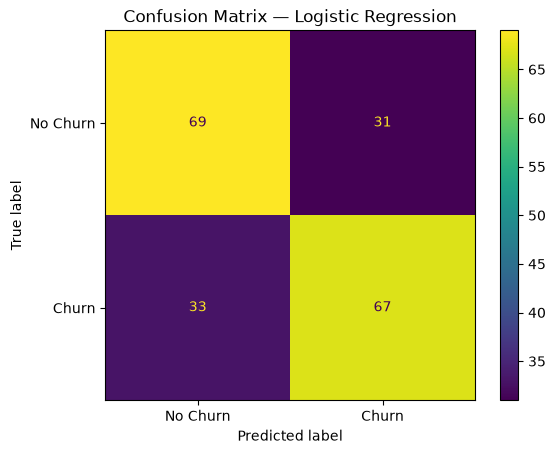

True negatives:  69
False positives: 31
False negatives: 33
True positives:  67


In [36]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
display.plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")


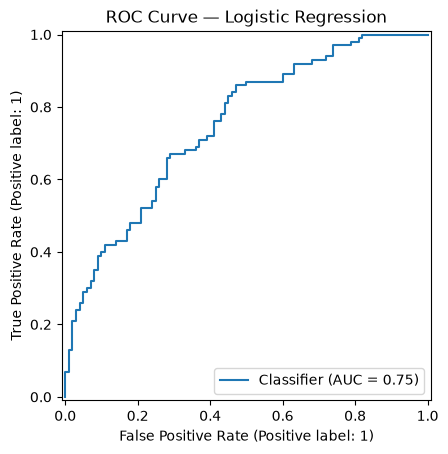

In [37]:
# ROC curve shows how well the model separates churn from non-churn
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — Logistic Regression")
plt.show()


## 8. Coefficient interpretation

Because the predictors were standardized, each coefficient represents the effect of roughly a one-standard-deviation increase in that feature while the other variables are held constant.

A positive coefficient increases the model's estimated odds of churn. A negative coefficient decreases them.

The odds ratio is calculated as:

\[
\text{odds ratio} = e^{\beta}
\]

An odds ratio above 1 increases churn odds, while a value below 1 decreases them.


In [38]:
model = logistic_pipeline.named_steps["model"]

coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coef_table["Odds Ratio"] = np.exp(coef_table["Coefficient"])
coef_table["Absolute Effect"] = coef_table["Coefficient"].abs()

coef_table = coef_table.sort_values("Absolute Effect", ascending=False).drop(columns="Absolute Effect")
coef_table.round(3)


,Feature,Coefficient,Odds Ratio
1,monthly_charges,0.647,1.909
5,contract_months,0.536,1.710
3,avg_session_minutes,0.508,1.662
2,support_tickets,-0.448,0.639
4,late_payments,-0.428,0.652
0,tenure_months,-0.351,0.704


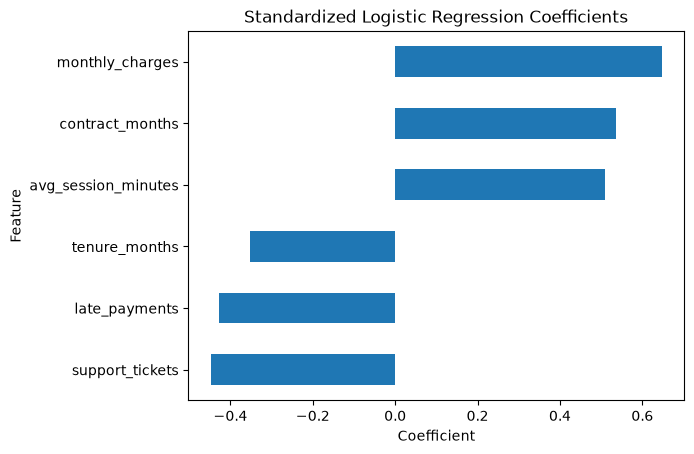

In [39]:
# Plot coefficients so the direction and relative strength are easier to compare
plot_coefs = coef_table.set_index("Feature")["Coefficient"].sort_values()

plot_coefs.plot(kind="barh")
plt.title("Standardized Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()


### Practical interpretation

In this fitted model, `monthly_charges` has the strongest positive coefficient, followed by `contract_months` and `avg_session_minutes`. This means higher values of those variables are associated with a higher estimated chance of churn, after accounting for the other predictors.

`support_tickets`, `late_payments` and `tenure_months` have negative coefficients in this synthetic dataset. In other words, higher values of those variables are associated with lower estimated churn odds in the fitted model.

Some of these directions may be surprising in a real business setting. The dataset is synthetic, so the coefficients should be treated as patterns in this dataset rather than universal customer-behaviour rules.


## 9. Results and conclusion

Using the fixed 80/20 stratified split, the Logistic Regression model achieved approximately:

- **Accuracy:** 0.68
- **Precision:** 0.684
- **Recall:** 0.67
- **F1-score:** 0.677
- **ROC-AUC:** 0.749

The confusion matrix contains 69 true negatives, 31 false positives, 33 false negatives and 67 true positives.

This is clearly better than the simple majority-class baseline, which only reaches 50% accuracy and an ROC-AUC of 0.50. The ROC-AUC of about 0.75 suggests the Logistic Regression model has a useful but not exceptional ability to rank churners above non-churners.

For a basic churn-screening model, this is a reasonable starting point, but it would not be strong enough to rely on blindly for important customer-retention decisions.


## 10. Limitations and possible improvements

There are a few important limitations:

1. **The data is synthetic.** The patterns may not behave the same way with real subscription customers.
2. **Only six predictors are available.** Real churn can depend on many other factors such as customer complaints, product usage trends, service outages, plan changes and demographics.
3. **Some predictors contain statistical outliers.** They were kept because the project brief does not provide valid business ranges, but they could influence the fitted coefficients.
4. **Only one train/test split is reported.** Cross-validation would give a more stable estimate of generalization performance.
5. **The default 0.50 decision threshold may not be best for the business.** If missing a churner is more expensive than contacting a customer who would have stayed, the threshold could be adjusted to improve recall.
6. **Logistic Regression assumes a linear relationship with the log-odds.** Real customer behaviour may involve nonlinear relationships and feature interactions.

Possible improvements would include cross-validation, threshold tuning, better domain-based data cleaning, additional features, regularization tuning and comparison with other classification models where technically justified.


## Final summary

The project followed the full workflow: inspect the data → check quality → split the data safely → scale features → build a baseline → train Logistic Regression → evaluate the model → interpret coefficients → discuss limitations.

The final model improves meaningfully over the baseline and provides interpretable feature effects, but its moderate performance and the synthetic nature of the dataset mean it should be treated as a learning model rather than a production-ready churn system.
